# 2.7 — Sanity Check: Aggregated Demand Datasets

Visual sanity checks for the 12 aggregated demand datasets produced by `01_07_Data_Aggregation`.

**Checks:**
- Row counts and grid completeness
- `trip_count` distributions (histograms, tails)
- Demand by hour-of-day, day-of-week, month
- Zero-demand share across resolutions
- Supply features: `active_taxis`, `avg_idle_time`
- Trip characteristics: fare, distance, duration, tip rate
- Weather correlations
- Area-type breakdown
- Temporal resolution comparison (same dataset, 4 freq)


### Data Requirements:

This notebook requires the following files:

1. The 12 aggregated demand datasets (produced by `01_07_Data_Aggregation`) — local paths: `data/aggregated/community_area/demand_ca_{1h,2h,6h,24h}.parquet` and `data/aggregated/hexagon/demand_hex_{1h,2h,6h,24h}_{low,medium}.parquet` — Sciebo path: `data_parquet/aggregated/...`

2. `Boundaries_Community_Areas_20260608.geojson` — local path: `data/geometry/Boundaries_Community_Areas_20260608.geojson` — Sciebo path: `data_parquet/geometry/Boundaries_Community_Areas_20260608.geojson`

Sample data is provided in the appropriate locations for testing purposes only. It will not produce meaningful results.


In [1]:
import os
from pathlib import Path
import __main__
_nb = getattr(__main__, "__vsc_ipynb_file__", None) or os.environ.get("JPY_SESSION_NAME")
_start = Path(_nb).resolve().parent if _nb else Path.cwd()
os.chdir(next(p for p in [_start, *_start.parents] if (p / "pyproject.toml").exists()))
print(f"Working directory: {os.getcwd()}")

Working directory: /Users/hendrik/Coding/Master/AAA


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams["figure.dpi"] = 120

In [3]:
# Load all 12 datasets into a dict keyed by (freq, spatial)
FREQS    = ["1h", "2h", "6h", "24h"]
SPATIALS = ["low", "medium", "ca"]

def path_for(freq, spatial):
    if spatial == "ca":
        return f"data/aggregated/community_area/demand_ca_{freq}.parquet"
    return f"data/aggregated/hexagon/demand_hex_{freq}_{spatial}.parquet"

datasets = {}
for freq in FREQS:
    for spatial in SPATIALS:
        df = pd.read_parquet(path_for(freq, spatial))
        datasets[(freq, spatial)] = df
        print(f"[{freq:>3} | {spatial:6}]  rows={len(df):>9,}  cols={df.shape[1]}  zero%={round((df['trip_count']==0).mean()*100,1)}")

[ 1h | low   ]  rows=  289,080  cols=47  zero%=31.5
[ 1h | medium]  rows=1,401,600  cols=47  zero%=54.7
[ 1h | ca    ]  rows=  674,520  cols=47  zero%=45.7
[ 2h | low   ]  rows=  144,540  cols=47  zero%=23.7
[ 2h | medium]  rows=  700,800  cols=47  zero%=42.8
[ 2h | ca    ]  rows=  337,260  cols=47  zero%=32.6
[ 6h | low   ]  rows=   48,180  cols=47  zero%=14.4
[ 6h | medium]  rows=  233,600  cols=47  zero%=24.1
[ 6h | ca    ]  rows=  112,420  cols=47  zero%=14.9
[24h | low   ]  rows=   12,045  cols=47  zero%=7.0
[24h | medium]  rows=   58,400  cols=47  zero%=7.0
[24h | ca    ]  rows=   28,105  cols=47  zero%=1.1


## 1 — Grid completeness

Every `(time_bucket × cell)` combination must exist. Row count = expected buckets × active cells.

In [4]:
START = pd.Timestamp("2025-01-01")
END   = pd.Timestamp("2026-01-01")

rows = []
for (freq, spatial), df in datasets.items():
    expected_buckets = len(pd.date_range(START, END, freq=freq, inclusive="left"))
    spatial_col = "pickup_community_area" if spatial == "ca" else ("pickup_h3_res6" if spatial == "low" else "pickup_h3_res7")
    n_cells = df[spatial_col].nunique()
    expected_rows = expected_buckets * n_cells
    actual_rows   = len(df)
    rows.append(dict(freq=freq, spatial=spatial,
                     expected_buckets=expected_buckets, n_cells=n_cells,
                     expected_rows=expected_rows, actual_rows=actual_rows,
                     ok=(expected_rows == actual_rows)))

grid_df = pd.DataFrame(rows)
print(grid_df.to_string(index=False))
assert grid_df["ok"].all(), "GRID MISMATCH — some datasets are incomplete!"
print("\nAll grids complete.")

freq spatial  expected_buckets  n_cells  expected_rows  actual_rows   ok
  1h     low              8760       33         289080       289080 True
  1h  medium              8760      160        1401600      1401600 True
  1h      ca              8760       77         674520       674520 True
  2h     low              4380       33         144540       144540 True
  2h  medium              4380      160         700800       700800 True
  2h      ca              4380       77         337260       337260 True
  6h     low              1460       33          48180        48180 True
  6h  medium              1460      160         233600       233600 True
  6h      ca              1460       77         112420       112420 True
 24h     low               365       33          12045        12045 True
 24h  medium               365      160          58400        58400 True
 24h      ca               365       77          28105        28105 True

All grids complete.


## 2 — `trip_count` distribution

Histograms of non-zero trip counts (log scale) and zero-demand share per dataset.

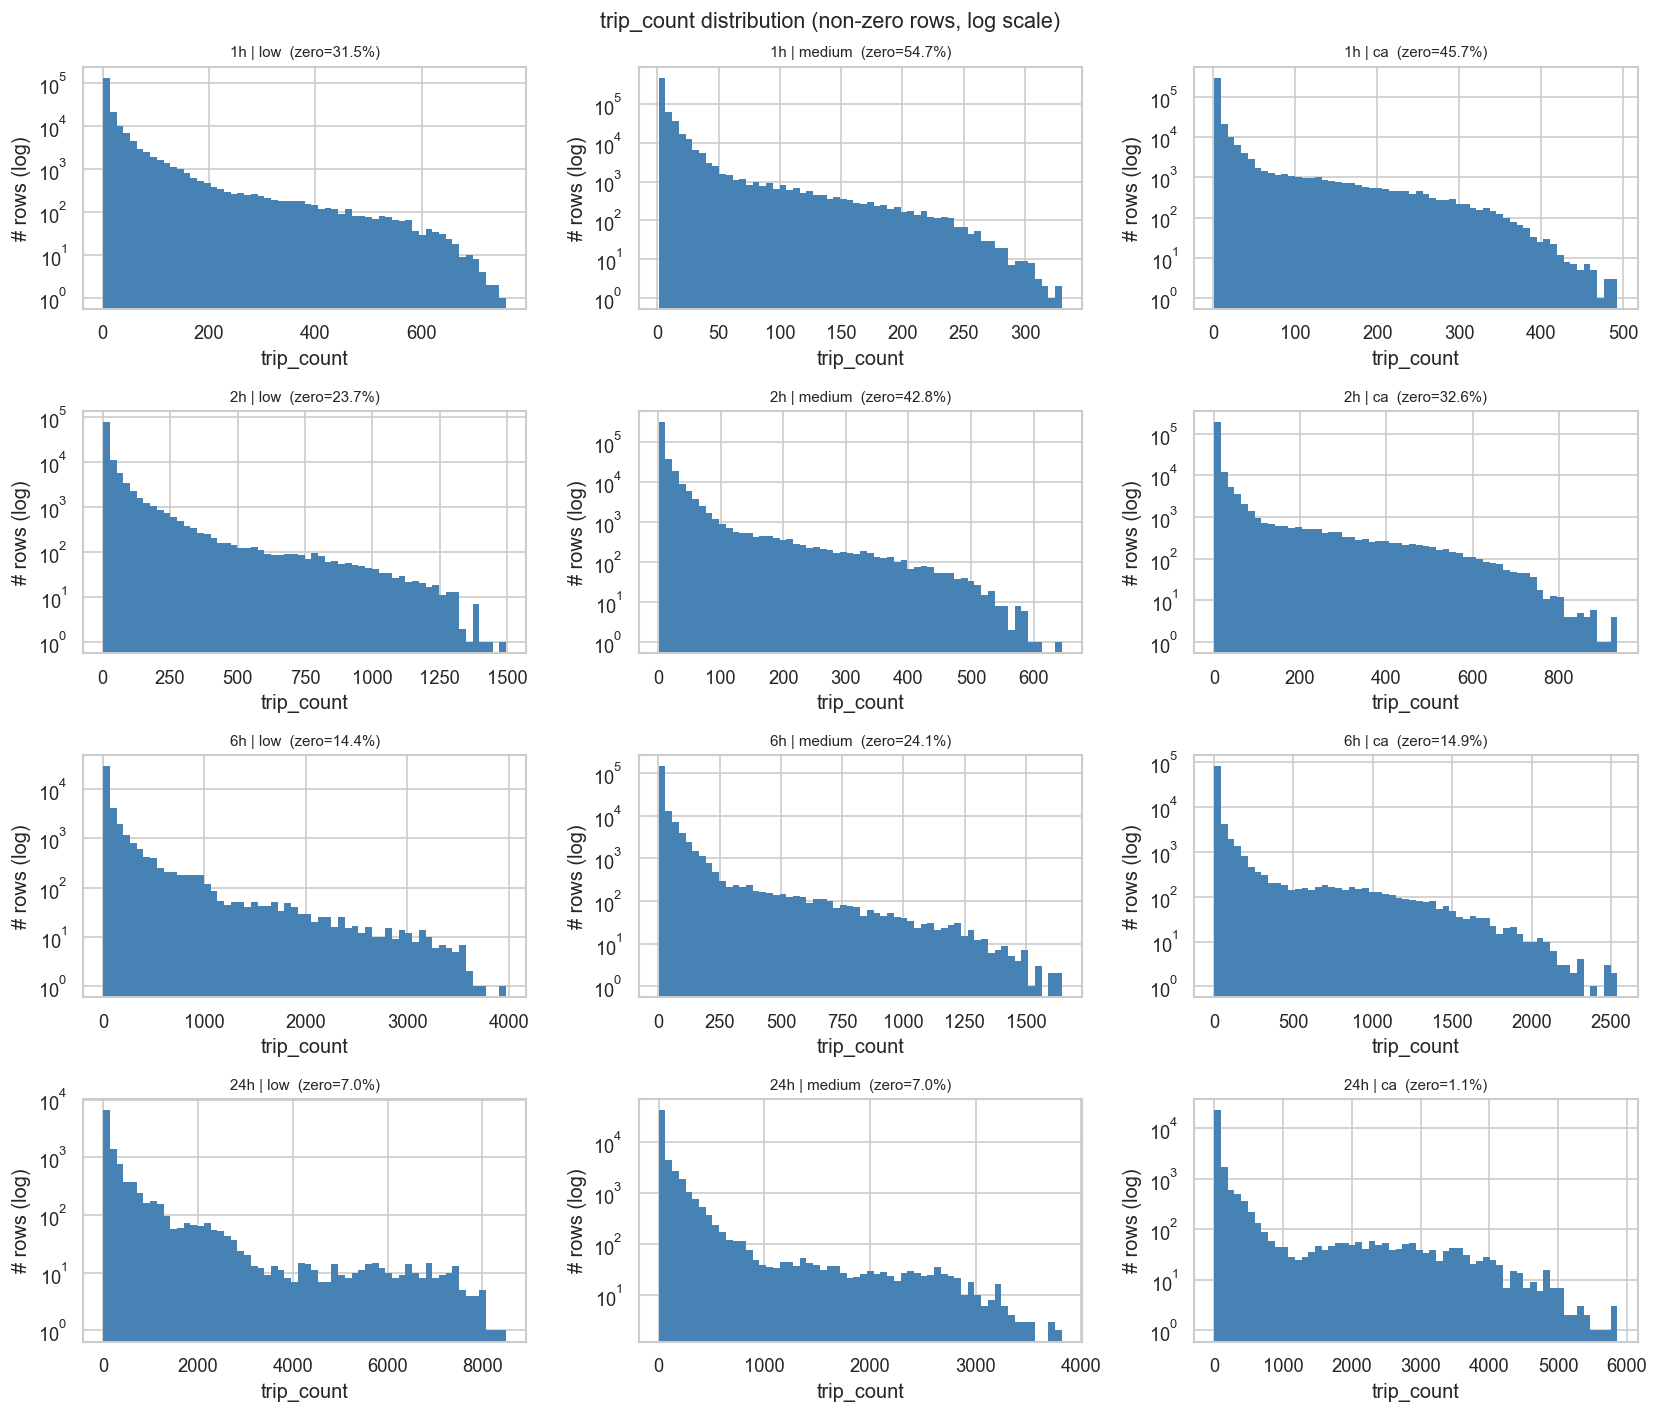

In [5]:
fig, axes = plt.subplots(4, 3, figsize=(14, 12), sharey=False)
fig.suptitle("trip_count distribution (non-zero rows, log scale)", fontsize=13)

for row_i, freq in enumerate(FREQS):
    for col_i, spatial in enumerate(SPATIALS):
        ax  = axes[row_i][col_i]
        df  = datasets[(freq, spatial)]
        nz  = df.loc[df["trip_count"] > 0, "trip_count"]
        ax.hist(nz, bins=60, log=True, color="steelblue", edgecolor="none")
        ax.set_title(f"{freq} | {spatial}  (zero={round((df['trip_count']==0).mean()*100,1)}%)", fontsize=9)
        ax.set_xlabel("trip_count")
        ax.set_ylabel("# rows (log)")

plt.tight_layout()
plt.show()

/var/folders/cn/fgq6fx4941j6hk598s_2v6t00000gn/T/ipykernel_2524/2824790711.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(zero_pct["label"], rotation=40, ha="right")


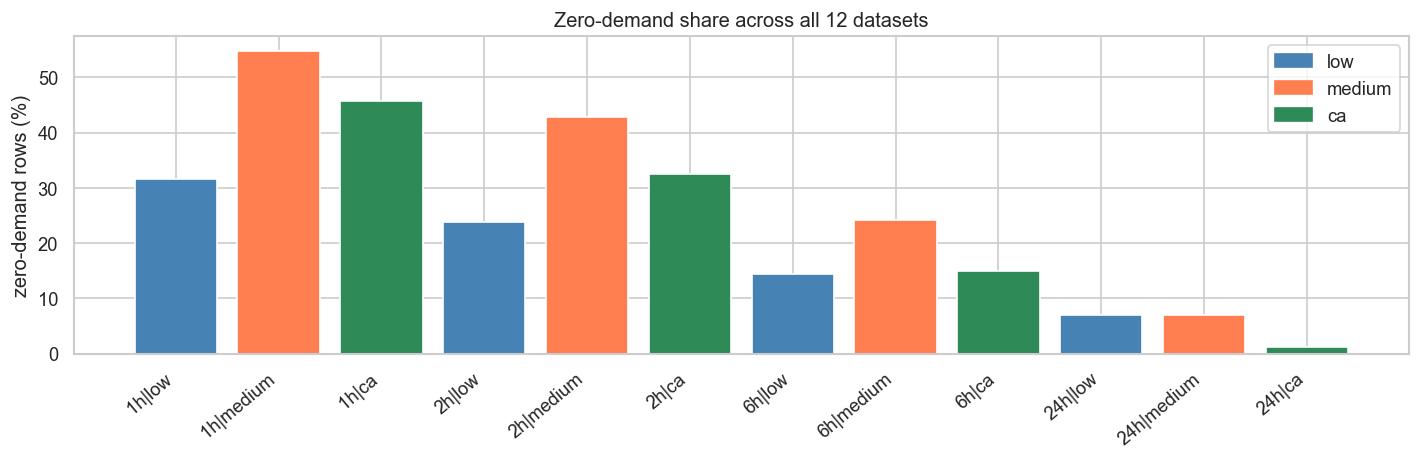

In [6]:
zero_pct = pd.DataFrame([
    dict(label=f"{freq}|{spatial}", freq=freq, spatial=spatial,
         zero_pct=(datasets[(freq, spatial)]["trip_count"] == 0).mean() * 100)
    for freq in FREQS for spatial in SPATIALS
])

fig, ax = plt.subplots(figsize=(12, 4))
colors = {"low": "steelblue", "medium": "coral", "ca": "seagreen"}
bars = ax.bar(zero_pct["label"], zero_pct["zero_pct"],
              color=[colors[s] for s in zero_pct["spatial"]])
ax.set_ylabel("zero-demand rows (%)")
ax.set_title("Zero-demand share across all 12 datasets")
ax.set_xticklabels(zero_pct["label"], rotation=40, ha="right")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=l) for l, c in colors.items()])
plt.tight_layout()
plt.show()

## 3 — Temporal demand patterns

Using the CA / 1h dataset (most informative). Demand by hour, day-of-week, and month.

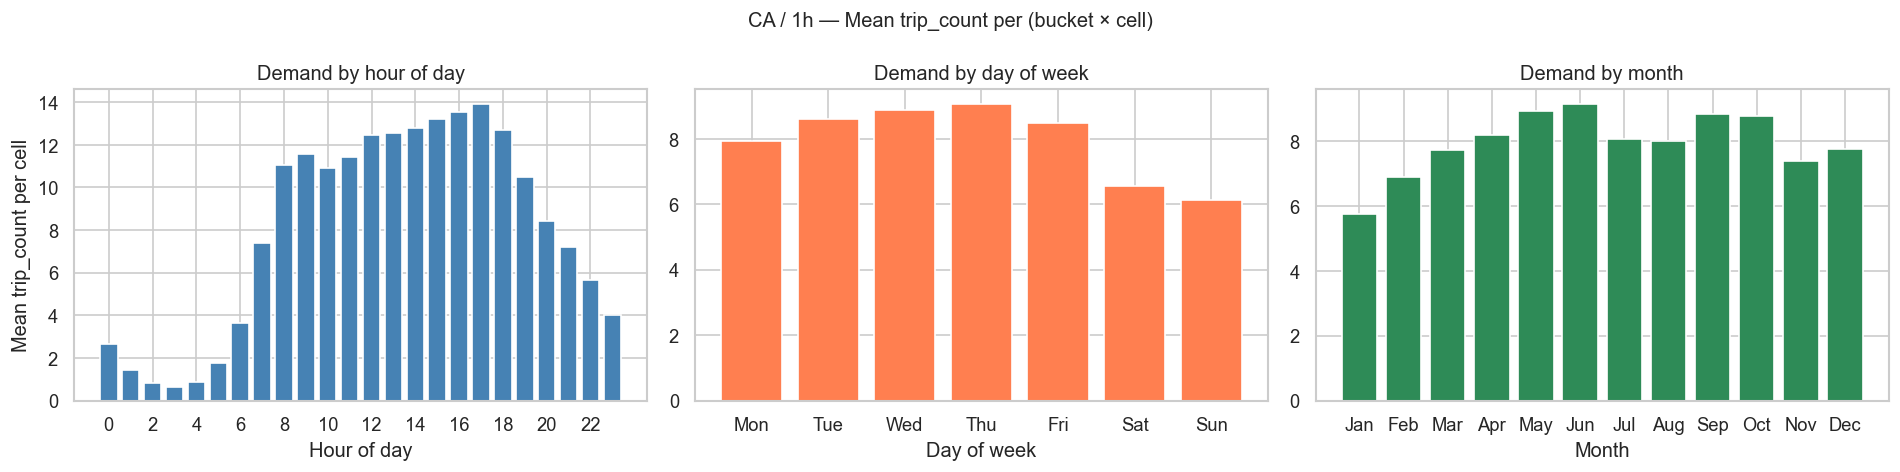

In [7]:
df1h_ca = datasets[("1h", "ca")]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- Hour of day ---
hod = df1h_ca.groupby("hour_of_day")["trip_count"].mean()
axes[0].bar(hod.index, hod.values, color="steelblue")
axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel("Mean trip_count per cell")
axes[0].set_title("Demand by hour of day")
axes[0].set_xticks(range(0, 24, 2))

# --- Day of week ---
dow_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
dow = df1h_ca.groupby("day_of_week")["trip_count"].mean()
axes[1].bar(dow_labels, dow.values, color="coral")
axes[1].set_xlabel("Day of week")
axes[1].set_title("Demand by day of week")

# --- Month ---
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
mon = df1h_ca.groupby("month")["trip_count"].mean()
axes[2].bar(month_labels, mon.values, color="seagreen")
axes[2].set_xlabel("Month")
axes[2].set_title("Demand by month")

plt.suptitle("CA / 1h — Mean trip_count per (bucket × cell)", fontsize=12)
plt.tight_layout()
plt.show()

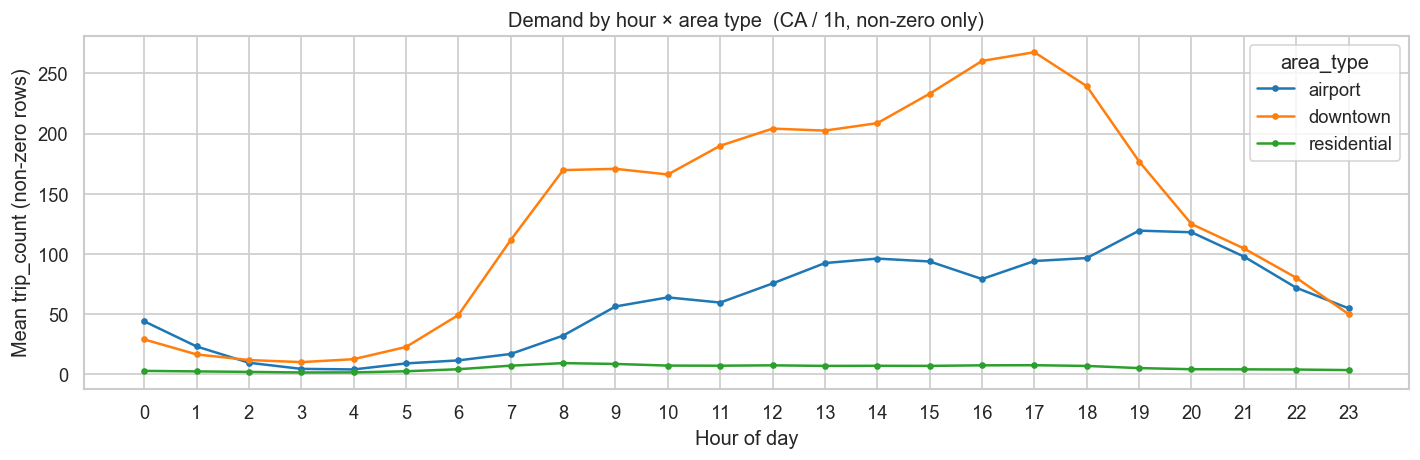

In [8]:
# Demand by hour × area_type (exclude zeros for a clearer supply/demand signal)
nz = df1h_ca[df1h_ca["trip_count"] > 0]
hod_area = nz.groupby(["hour_of_day", "area_type"])["trip_count"].mean().unstack()

fig, ax = plt.subplots(figsize=(12, 4))
hod_area.plot(ax=ax, marker="o", markersize=3)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean trip_count (non-zero rows)")
ax.set_title("Demand by hour × area type  (CA / 1h, non-zero only)")
ax.set_xticks(range(0, 24))
ax.legend(title="area_type")
plt.tight_layout()
plt.show()

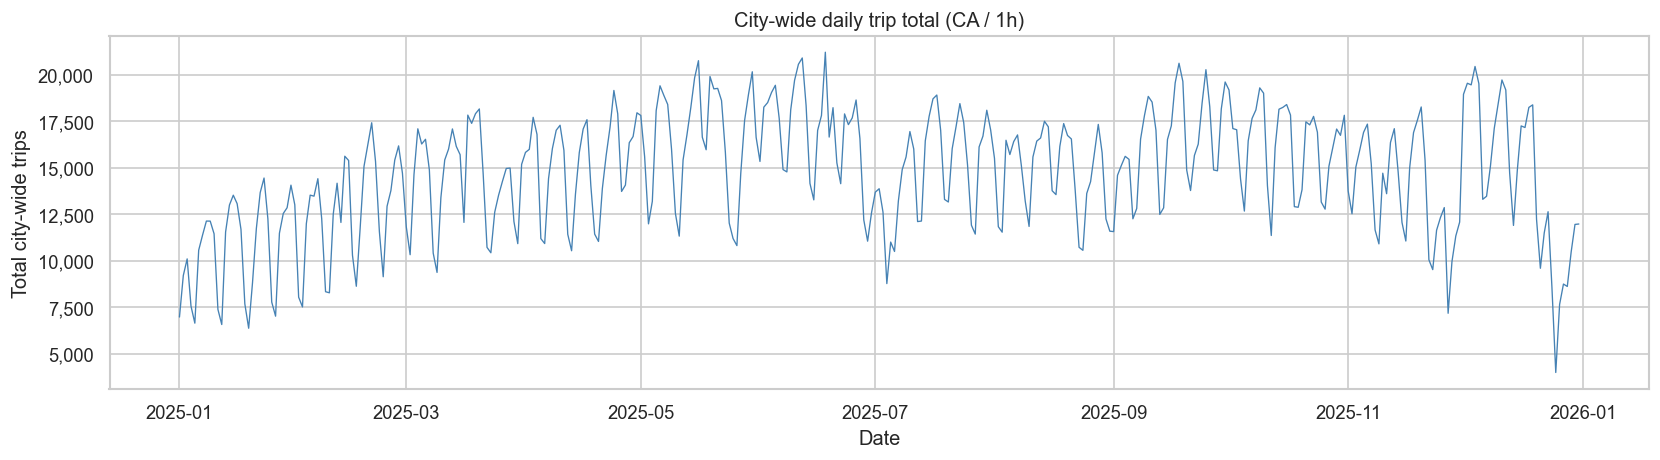

In [9]:
# City-wide daily total demand (sum over all cells per day)
daily = (df1h_ca
         .groupby(df1h_ca["time_bucket"].dt.date)["trip_count"]
         .sum()
         .rename("total_trips")
         .reset_index()
         .rename(columns={"time_bucket": "date"}))
daily["date"] = pd.to_datetime(daily["date"])

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily["date"], daily["total_trips"], linewidth=0.8, color="steelblue")
ax.set_xlabel("Date")
ax.set_ylabel("Total city-wide trips")
ax.set_title("City-wide daily trip total (CA / 1h)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

## 4 — Supply features: `active_taxis` & `avg_idle_time`

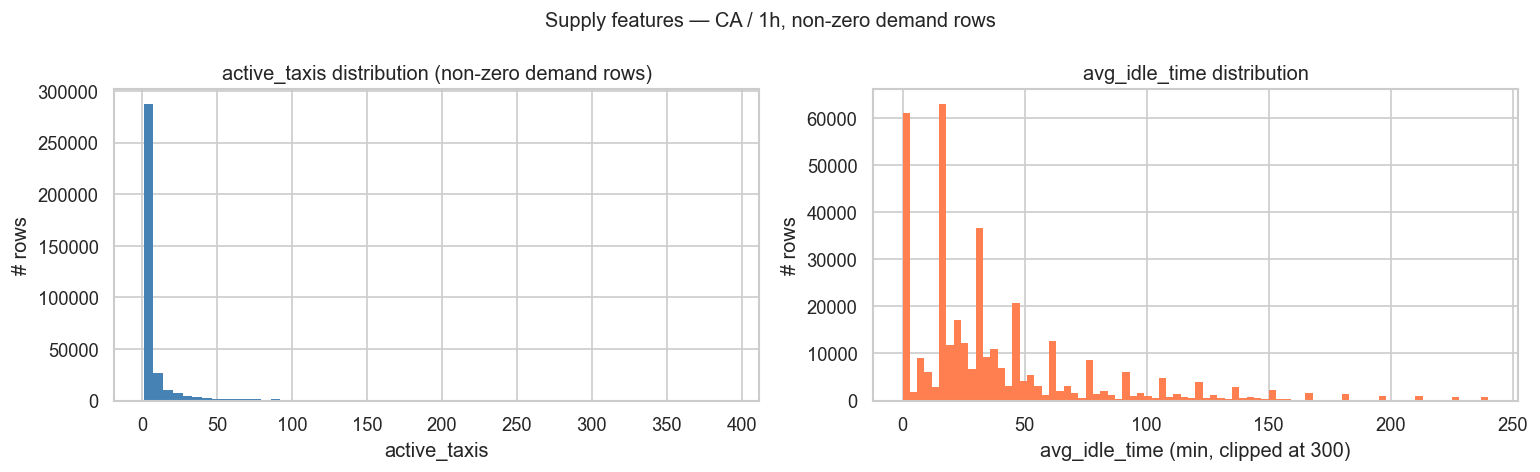

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

nz = df1h_ca[df1h_ca["trip_count"] > 0]

axes[0].hist(nz["active_taxis"], bins=60, color="steelblue", edgecolor="none")
axes[0].set_xlabel("active_taxis")
axes[0].set_ylabel("# rows")
axes[0].set_title("active_taxis distribution (non-zero demand rows)")

axes[1].hist(nz["avg_idle_time"].clip(upper=300), bins=80, color="coral", edgecolor="none")
axes[1].set_xlabel("avg_idle_time (min, clipped at 300)")
axes[1].set_ylabel("# rows")
axes[1].set_title("avg_idle_time distribution")

plt.suptitle("Supply features — CA / 1h, non-zero demand rows", fontsize=12)
plt.tight_layout()
plt.show()

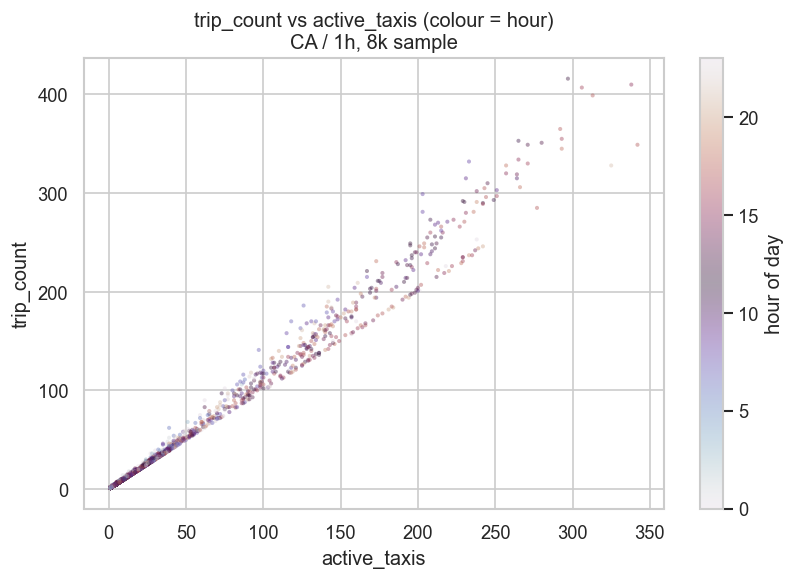

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
sample = nz.sample(min(8000, len(nz)), random_state=42)
scatter = ax.scatter(sample["active_taxis"], sample["trip_count"],
                     c=sample["hour_of_day"], cmap="twilight",
                     alpha=0.4, s=6, linewidths=0)
plt.colorbar(scatter, ax=ax, label="hour of day")
ax.set_xlabel("active_taxis")
ax.set_ylabel("trip_count")
ax.set_title("trip_count vs active_taxis (colour = hour)\nCA / 1h, 8k sample")
plt.tight_layout()
plt.show()

## 5 — Trip characteristics

Distributions of fare, distance, duration, and tip rate for non-zero demand buckets.

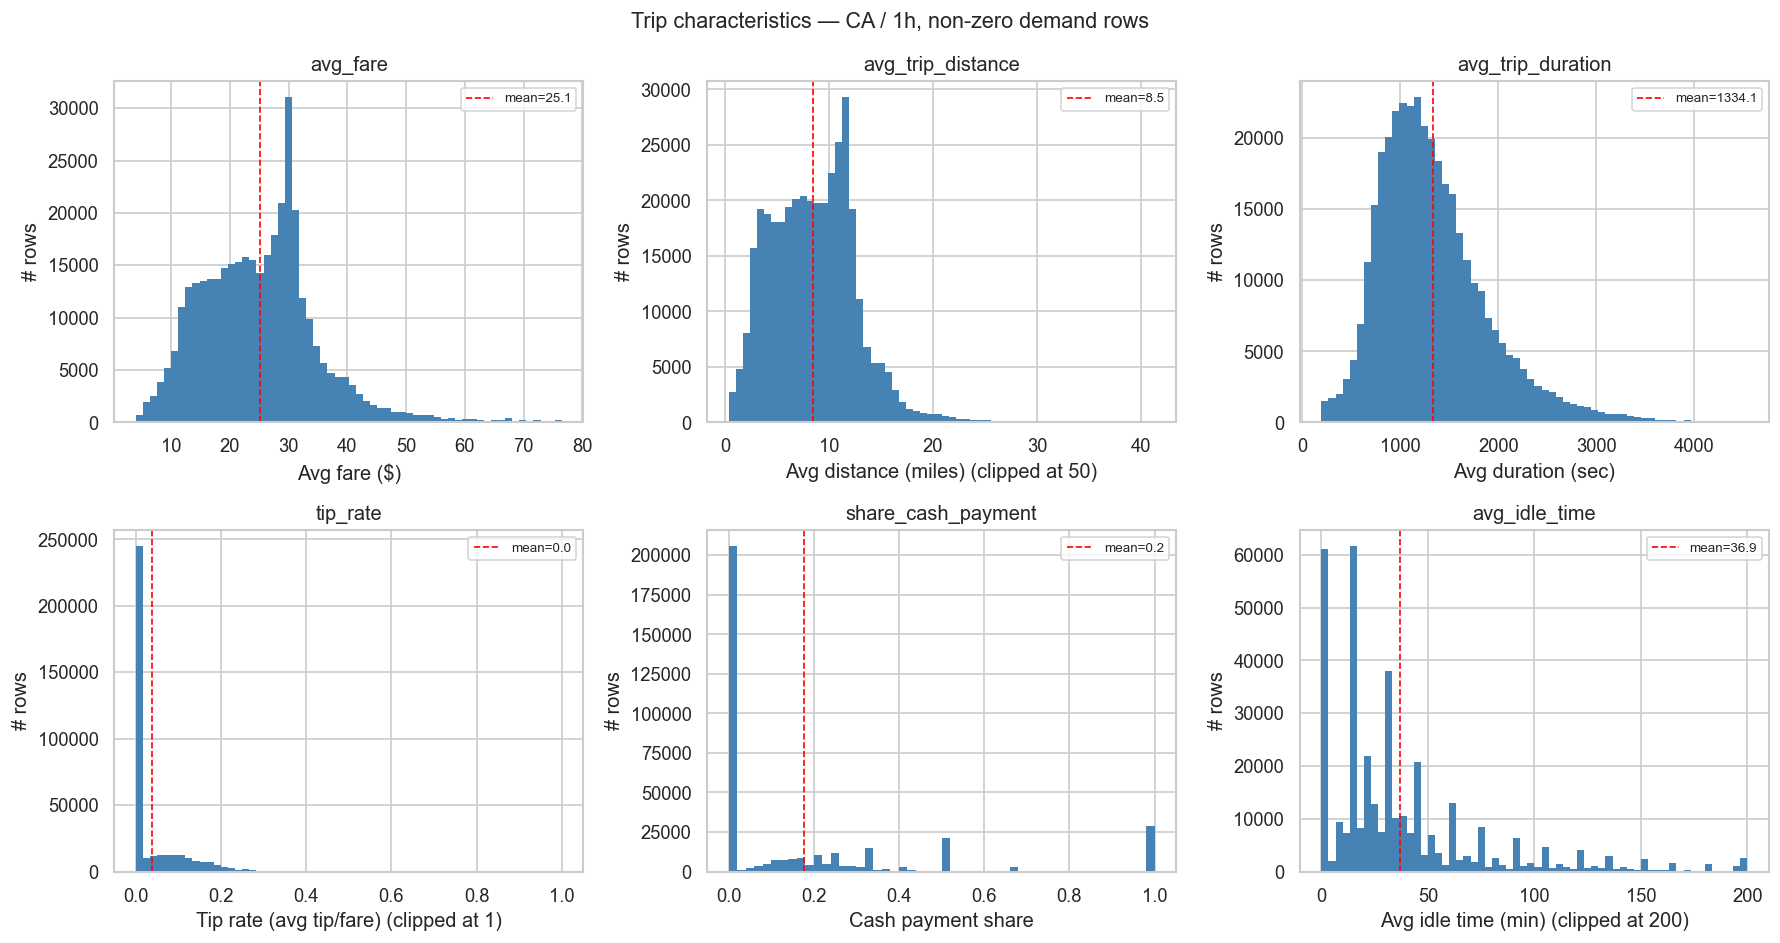

In [12]:
metrics = [
    ("avg_fare",          "Avg fare ($)",         60,   None),
    ("avg_trip_distance", "Avg distance (miles)",  60,   50),
    ("avg_trip_duration", "Avg duration (sec)",    60,   None),
    ("tip_rate",          "Tip rate (avg tip/fare)",60,   1),
    ("share_cash_payment","Cash payment share",    50,   None),
    ("avg_idle_time",     "Avg idle time (min)",   60,   200),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (col, label, bins, clip_at) in zip(axes.flat, metrics):
    vals = nz[col]
    if clip_at is not None:
        vals = vals.clip(upper=clip_at)
    ax.hist(vals, bins=bins, color="steelblue", edgecolor="none")
    ax.set_xlabel(label + (f" (clipped at {clip_at})" if clip_at else ""))
    ax.set_ylabel("# rows")
    ax.set_title(col)
    mean_val = vals.mean()
    ax.axvline(mean_val, color="red", linestyle="--", linewidth=1, label=f"mean={mean_val:.1f}")
    ax.legend(fontsize=8)

plt.suptitle("Trip characteristics — CA / 1h, non-zero demand rows", fontsize=13)
plt.tight_layout()
plt.show()

/var/folders/cn/fgq6fx4941j6hk598s_2v6t00000gn/T/ipykernel_2524/2843829494.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_area, labels=["downtown", "airport", "residential"], patch_artist=True,
/var/folders/cn/fgq6fx4941j6hk598s_2v6t00000gn/T/ipykernel_2524/2843829494.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_area, labels=["downtown", "airport", "residential"], patch_artist=True,


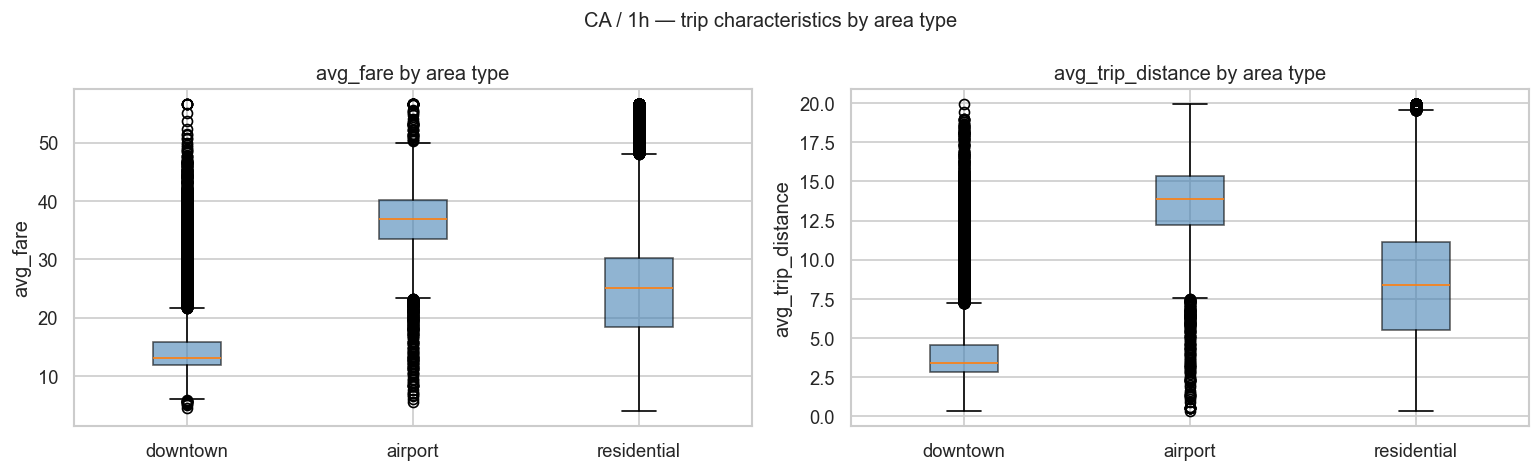

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col in zip(axes, ["avg_fare", "avg_trip_distance"]):
    data_by_area = [nz.loc[nz["area_type"] == a, col].clip(upper=nz[col].quantile(0.99))
                    for a in ["downtown", "airport", "residential"]]
    ax.boxplot(data_by_area, labels=["downtown", "airport", "residential"], patch_artist=True,
               boxprops=dict(facecolor="steelblue", alpha=0.6))
    ax.set_ylabel(col)
    ax.set_title(f"{col} by area type")

plt.suptitle("CA / 1h — trip characteristics by area type", fontsize=12)
plt.tight_layout()
plt.show()

## 6 — Weather correlations with demand

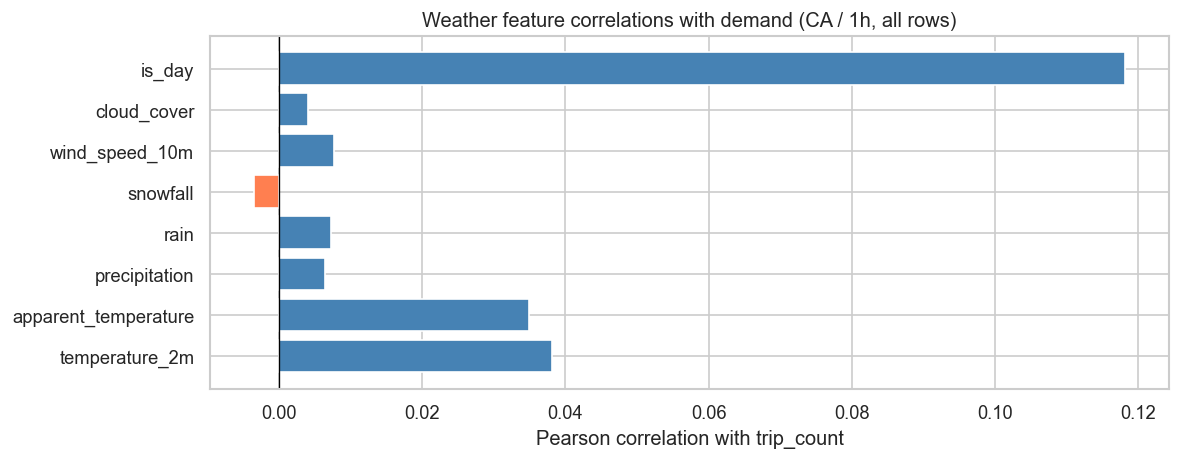

snowfall               -0.003566
cloud_cover             0.004068
precipitation           0.006470
rain                    0.007275
wind_speed_10m          0.007698
apparent_temperature    0.034835
temperature_2m          0.038125
is_day                  0.118206
Name: trip_count, dtype: float64


In [14]:
WEATHER_COLS = [
    "temperature_2m", "apparent_temperature", "precipitation",
    "rain", "snowfall", "wind_speed_10m", "cloud_cover", "is_day",
]

# Correlations with trip_count (all rows, incl. zeros)
corrs = df1h_ca[WEATHER_COLS + ["trip_count"]].corr()["trip_count"].drop("trip_count")

fig, ax = plt.subplots(figsize=(10, 4))
colors_bar = ["steelblue" if c >= 0 else "coral" for c in corrs]
ax.barh(corrs.index, corrs.values, color=colors_bar)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson correlation with trip_count")
ax.set_title("Weather feature correlations with demand (CA / 1h, all rows)")
plt.tight_layout()
plt.show()

print(corrs.sort_values())

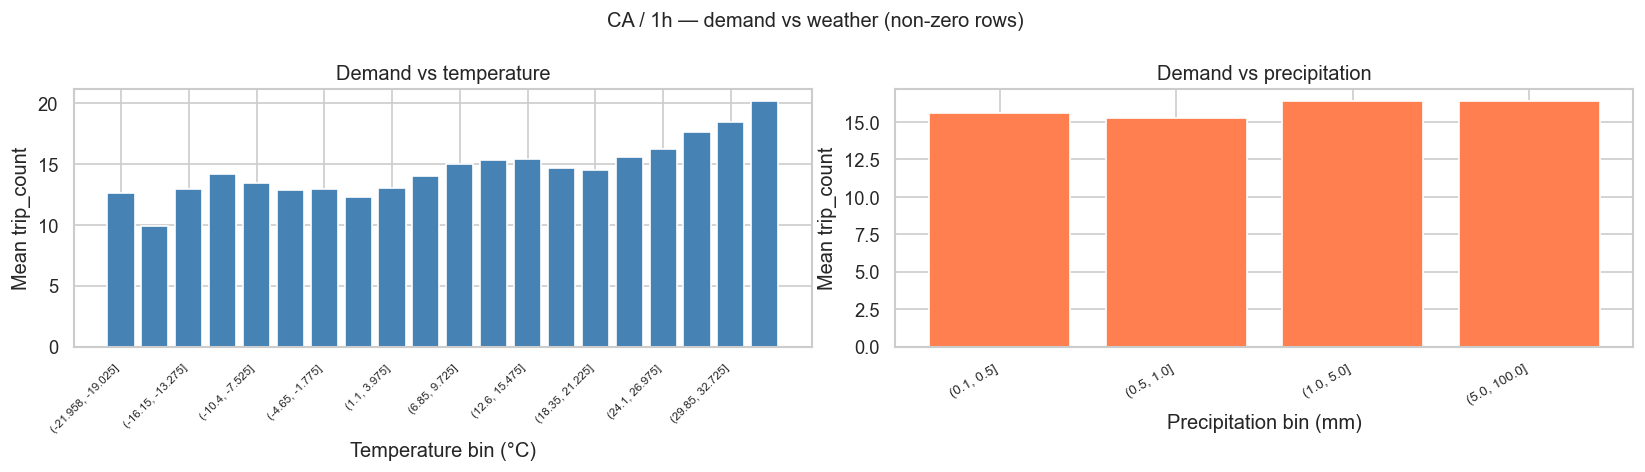

In [15]:
# Demand vs temperature (bin by temperature, mean trip_count)
df_tmp = df1h_ca[df1h_ca["trip_count"] > 0].copy()
df_tmp["temp_bin"] = pd.cut(df_tmp["temperature_2m"], bins=20)
temp_demand = df_tmp.groupby("temp_bin", observed=True)["trip_count"].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(len(temp_demand)), temp_demand.values, color="steelblue")
axes[0].set_xticks(range(0, len(temp_demand), 2))
axes[0].set_xticklabels([str(b) for b in temp_demand.index[::2]], rotation=45, ha="right", fontsize=7)
axes[0].set_xlabel("Temperature bin (°C)")
axes[0].set_ylabel("Mean trip_count")
axes[0].set_title("Demand vs temperature")

# Demand vs precipitation
df_tmp["precip_bin"] = pd.cut(df_tmp["precipitation"], bins=[0, 0.01, 0.1, 0.5, 1, 5, 100])
precip_demand = df_tmp.groupby("precip_bin", observed=True)["trip_count"].mean()
axes[1].bar(range(len(precip_demand)), precip_demand.values, color="coral")
axes[1].set_xticks(range(len(precip_demand)))
axes[1].set_xticklabels([str(b) for b in precip_demand.index], rotation=30, ha="right", fontsize=8)
axes[1].set_xlabel("Precipitation bin (mm)")
axes[1].set_ylabel("Mean trip_count")
axes[1].set_title("Demand vs precipitation")

plt.suptitle("CA / 1h — demand vs weather (non-zero rows)", fontsize=12)
plt.tight_layout()
plt.show()

## 7 — Temporal resolution comparison

Same week of data at 1h / 2h / 6h / 24h for the CA spatial unit.

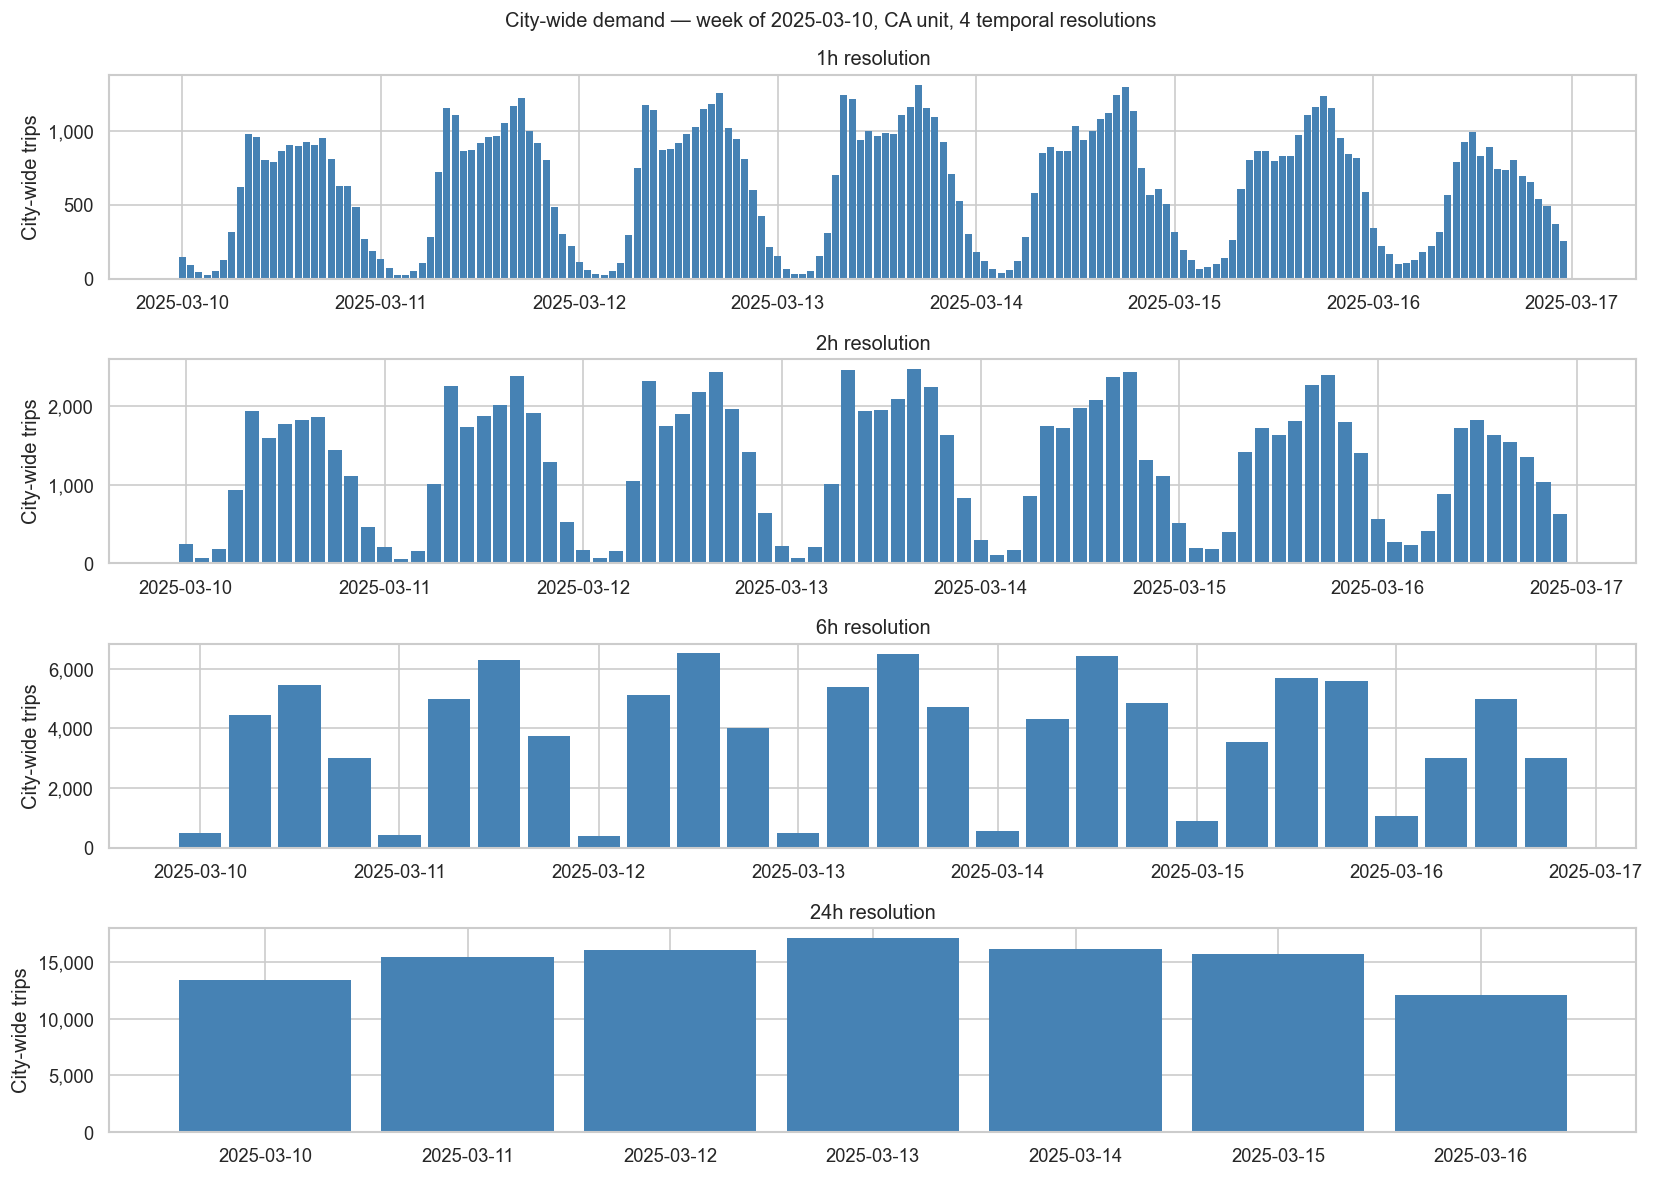

In [16]:
SAMPLE_WEEK_START = pd.Timestamp("2025-03-10")
SAMPLE_WEEK_END   = pd.Timestamp("2025-03-17")

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=False)

for ax, freq in zip(axes, FREQS):
    df = datasets[(freq, "ca")]
    mask = (df["time_bucket"] >= SAMPLE_WEEK_START) & (df["time_bucket"] < SAMPLE_WEEK_END)
    week = df[mask].groupby("time_bucket")["trip_count"].sum()
    ax.bar(week.index, week.values, width=pd.Timedelta(freq) * 0.85, color="steelblue", edgecolor="none")
    ax.set_ylabel("City-wide trips")
    ax.set_title(f"{freq} resolution")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.suptitle("City-wide demand — week of 2025-03-10, CA unit, 4 temporal resolutions", fontsize=12)
plt.tight_layout()
plt.show()

## 8 — Spatial resolution comparison

Trip-count distribution for 1h at H3-low, H3-medium, and CA.

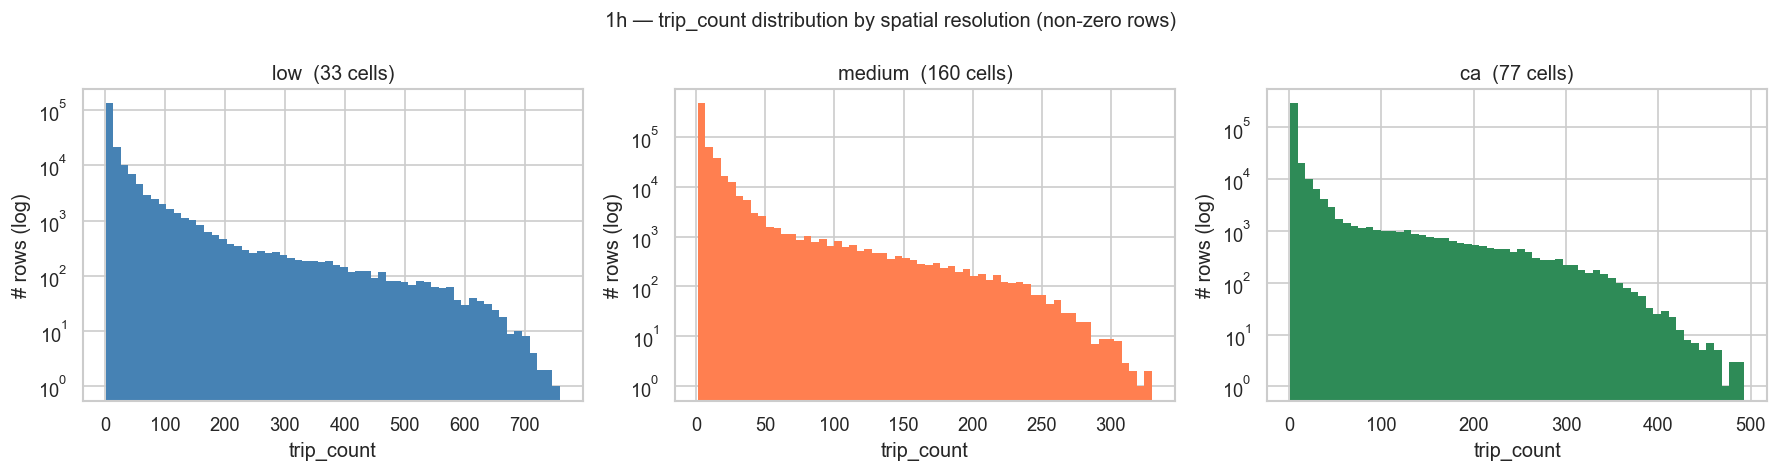

spatial  n_cells  zero_pct  p50  p90   p99  max_
    low       33      31.5  2.0 43.0 306.0   759
 medium      160      54.7  0.0  8.0  67.0   330
     ca       77      45.7  1.0 10.0 193.0   493


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
palette = {"low": "steelblue", "medium": "coral", "ca": "seagreen"}

for ax, spatial in zip(axes, SPATIALS):
    df  = datasets[("1h", spatial)]
    nz  = df.loc[df["trip_count"] > 0, "trip_count"]
    ax.hist(nz, bins=60, log=True, color=palette[spatial], edgecolor="none")
    ax.set_xlabel("trip_count")
    ax.set_ylabel("# rows (log)")
    spatial_col = "pickup_community_area" if spatial == "ca" else ("pickup_h3_res6" if spatial == "low" else "pickup_h3_res7")
    ax.set_title(f"{spatial}  ({df[spatial_col].nunique()} cells)")

plt.suptitle("1h — trip_count distribution by spatial resolution (non-zero rows)", fontsize=12)
plt.tight_layout()
plt.show()

# Summary table
summary = pd.DataFrame([
    dict(spatial=s,
         n_cells=datasets[("1h", s)][ "pickup_community_area" if s == "ca" else ("pickup_h3_res6" if s == "low" else "pickup_h3_res7")].nunique(),
         zero_pct=round((datasets[("1h", s)]["trip_count"] == 0).mean() * 100, 1),
         p50=datasets[("1h", s)]["trip_count"].median(),
         p90=datasets[("1h", s)]["trip_count"].quantile(0.90),
         p99=datasets[("1h", s)]["trip_count"].quantile(0.99),
         max_=datasets[("1h", s)]["trip_count"].max())
    for s in SPATIALS
])
print(summary.to_string(index=False))

## 9 — Demand heatmap: hour-of-day × day-of-week

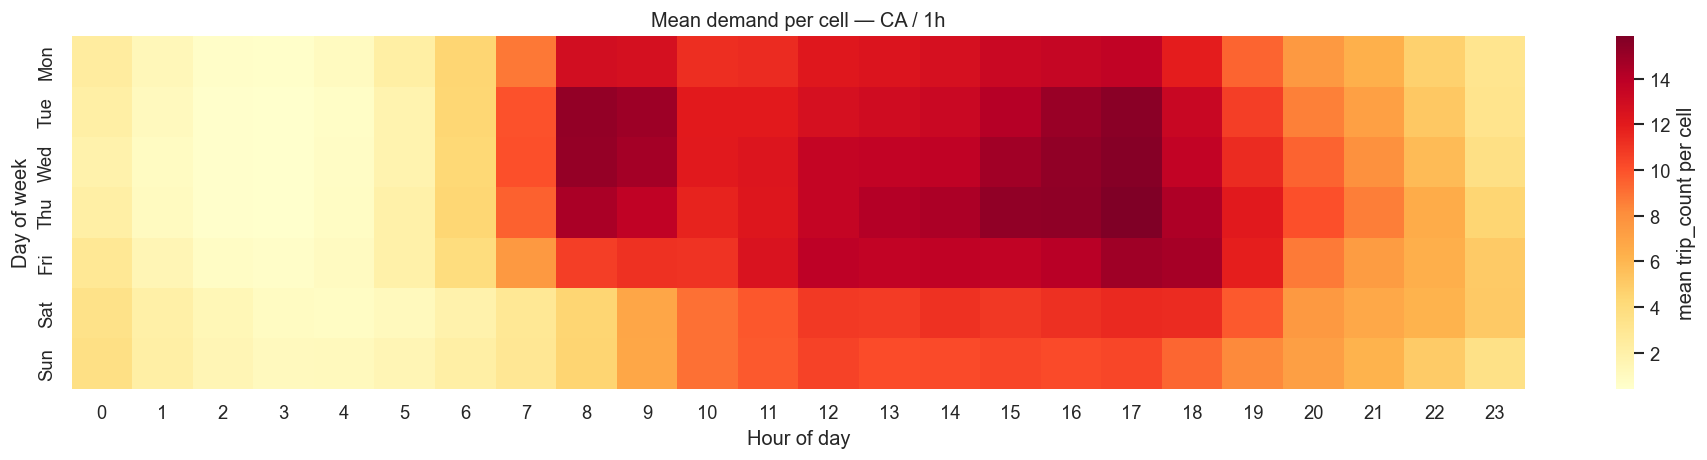

In [18]:
pivot = (df1h_ca
         .groupby(["day_of_week", "hour_of_day"])["trip_count"]
         .mean()
         .unstack("hour_of_day"))
pivot.index = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(pivot, ax=ax, cmap="YlOrRd", linewidths=0,
            cbar_kws={"label": "mean trip_count per cell"})
ax.set_xlabel("Hour of day")
ax.set_ylabel("Day of week")
ax.set_title("Mean demand per cell — CA / 1h")
plt.tight_layout()
plt.show()

## 10 — Top cells by total demand

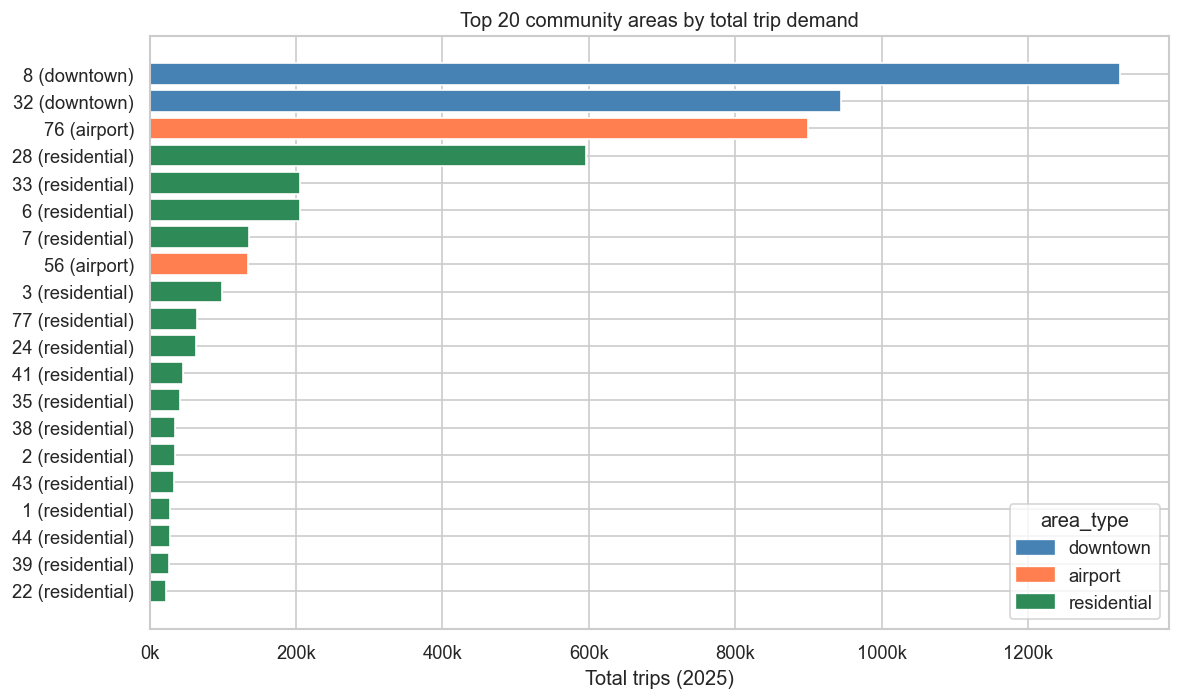

In [19]:
top_ca = (df1h_ca
          .groupby(["pickup_community_area", "area_type"])["trip_count"]
          .sum()
          .reset_index()
          .sort_values("trip_count", ascending=False)
          .head(20))

top_ca["label"] = top_ca["pickup_community_area"].astype(str) + " (" + top_ca["area_type"] + ")"

fig, ax = plt.subplots(figsize=(10, 6))
colors_area = {"downtown": "steelblue", "airport": "coral", "residential": "seagreen"}
bar_colors  = [colors_area[a] for a in top_ca["area_type"]]
ax.barh(top_ca["label"][::-1], top_ca["trip_count"][::-1], color=bar_colors[::-1])
ax.set_xlabel("Total trips (2025)")
ax.set_title("Top 20 community areas by total trip demand")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=l) for l, c in colors_area.items()], title="area_type")
plt.tight_layout()
plt.show()

## 11 — Null / NaN check across all 12 datasets

In [20]:
null_report = []
for (freq, spatial), df in datasets.items():
    total_nulls = int(df.isna().sum().sum())
    null_report.append(dict(freq=freq, spatial=spatial, total_nulls=total_nulls))

null_df = pd.DataFrame(null_report)
print(null_df.to_string(index=False))
if null_df["total_nulls"].sum() == 0:
    print("\nNo NaN values in any dataset.")
else:
    print("\nWARNING: NaN values found — investigate!")

freq spatial  total_nulls
  1h     low            0
  1h  medium            0
  1h      ca            0
  2h     low            0
  2h  medium            0
  2h      ca            0
  6h     low            0
  6h  medium            0
  6h      ca            0
 24h     low            0
 24h  medium            0
 24h      ca            0

No NaN values in any dataset.


## 12 — Summary statistics table

In [21]:
rows = []
for (freq, spatial), df in datasets.items():
    tc = df["trip_count"]
    rows.append(dict(
        freq=freq, spatial=spatial,
        rows=len(df),
        total_trips=int(tc.sum()),
        zero_pct=round((tc == 0).mean() * 100, 1),
        mean=round(tc.mean(), 2),
        p50=tc.median(),
        p90=round(tc.quantile(0.90), 1),
        p99=round(tc.quantile(0.99), 1),
        max_=int(tc.max()),
    ))

summary = pd.DataFrame(rows)
summary["total_trips"] = summary["total_trips"].map("{:,}".format)
summary["rows"]        = summary["rows"].map("{:,}".format)
print(summary.to_string(index=False))

freq spatial      rows total_trips  zero_pct   mean  p50    p90    p99  max_
  1h     low   289,080   5,369,356      31.5  18.57  2.0   43.0  306.0   759
  1h  medium 1,401,600   5,369,356      54.7   3.83  0.0    8.0   67.0   330
  1h      ca   674,520   5,369,356      45.7   7.96  1.0   10.0  193.0   493
  2h     low   144,540   5,369,356      23.7  37.15  5.0   87.0  607.6  1497
  2h  medium   700,800   5,369,356      42.8   7.66  1.0   16.0  134.0   645
  2h      ca   337,260   5,369,356      32.6  15.92  1.0   19.0  385.4   936
  6h     low    48,180   5,369,356      14.4 111.44 15.0  261.0 1743.4  3976
  6h  medium   233,600   5,369,356      24.1  22.99  3.0   48.0  413.0  1646
  6h      ca   112,420   5,369,356      14.9  47.76  5.0   59.0 1093.0  2541
 24h     low    12,045   5,369,356       7.0 445.77 77.0 1152.6 6157.4  8500
 24h  medium    58,400   5,369,356       7.0  91.94 14.0  209.0 1649.0  3816
 24h      ca    28,105   5,369,356       1.1 191.05 23.0  295.0 3545.0  5859

## 13 — Animated demand map over time

A choropleth that animates a chosen per-cell metric as the time bucket advances — a "video" of how demand (or any feature) moves across the city through the day/week.

**You select** (arguments of `animate_demand`, or the dropdowns in the last cell):
- `spatial` — `"low"` (H3 res 6), `"medium"` (H3 res 7) or `"ca"` (community areas)
- `freq` — `"1h"`, `"2h"`, `"6h"` or `"24h"`
- `metric` — any numeric column, e.g. `trip_count`, `avg_idle_time`, `avg_fare`, `active_taxis`
- `start` / `end` — the time window to animate (a full year at 1h is 8 760 frames, so pick a window; default = one week)

The colour scale is fixed across the clip (so frames are comparable), `MultiPolygon` cells like O'Hare are handled, and the result renders inline as a video with play/scrub controls — no ffmpeg needed. Pass `save_gif="path.gif"` to also export a GIF.

In [22]:
# --- Setup for the animated demand map ---
import geopandas as gpd
import h3
import numpy.ma as ma
from shapely.geometry import Polygon
from matplotlib.colors import Normalize, LogNorm
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML

# Community-area boundaries: the CA choropleth source and a city-outline backdrop for hex maps.
_ca = gpd.read_file("data/geometry/Boundaries_Community_Areas_20260608.geojson").to_crs(4326)
_ca["pickup_community_area"] = _ca["area_numbe"].astype(int)
COMMUNITY_AREAS = _ca[["pickup_community_area", "community", "geometry"]]
CITY_OUTLINE    = COMMUNITY_AREAS.dissolve().geometry.boundary   # single Chicago outline

SPATIAL_COL = {"low": "pickup_h3_res6", "medium": "pickup_h3_res7", "ca": "pickup_community_area"}


def cell_geometries(spatial, df):
    """Cell polygons indexed by the dataset's spatial-id column.

    MultiPolygon cells (e.g. O'Hare) are exploded into single polygons so the plotted
    collection has exactly one path per row — required for per-frame ``set_array`` updates.
    """
    col = SPATIAL_COL[spatial]
    if spatial == "ca":
        g = COMMUNITY_AREAS.set_index("pickup_community_area")[["geometry"]]
    else:
        cells = pd.Index(df[col].dropna().unique(), name=col)
        polys = [Polygon([(lon, lat) for lat, lon in h3.cell_to_boundary(c)]) for c in cells]
        g = gpd.GeoDataFrame({"geometry": polys}, index=cells, crs=4326)
    return g.explode(index_parts=False)


def animate_demand(spatial="ca", freq="1h", metric="trip_count",
                   start="2025-03-10", end="2025-03-17",
                   use_log=False, fps=6, max_frames=200, cmap_name="plasma", save_gif=None):
    """Animate a per-cell metric across time buckets as a choropleth "video".

    spatial : "low" (H3 res6) | "medium" (H3 res7) | "ca" (community areas)
    freq    : "1h" | "2h" | "6h" | "24h"
    metric  : any numeric column (trip_count, avg_idle_time, avg_fare, active_taxis, ...)
    start/end : time window to animate (a full year at 1h is 8 760 frames — pick a window)

    Returns an inline HTML video with play/scrub controls (no ffmpeg required).
    Pass save_gif="path.gif" to also export a GIF.
    """
    if (freq, spatial) not in datasets:
        raise KeyError(f"no dataset for freq={freq!r}, spatial={spatial!r}")
    col = SPATIAL_COL[spatial]
    df  = datasets[(freq, spatial)]
    start, end = pd.Timestamp(start), pd.Timestamp(end)

    dfw = df[(df["time_bucket"] >= start) & (df["time_bucket"] < end)]
    if dfw.empty:
        raise ValueError(f"no rows in window {start:%Y-%m-%d} .. {end:%Y-%m-%d}")

    gdf = cell_geometries(spatial, df)                       # rows may repeat a cell id (parts)
    piv = (dfw.pivot_table(index=col, columns="time_bucket", values=metric, aggfunc="first")
              .sort_index(axis=1))
    buckets = list(piv.columns)
    if len(buckets) > max_frames:                            # keep it light: even subsample
        sel = np.linspace(0, len(buckets) - 1, max_frames).astype(int)
        buckets = [buckets[i] for i in sel]

    # one colour scale for the whole clip so frames are comparable
    vmax = np.nanpercentile(piv.to_numpy(dtype=float), 99)
    if not np.isfinite(vmax) or vmax <= 0:
        vmax = 1.0
    norm = LogNorm(vmin=1, vmax=max(vmax, 2)) if use_log else Normalize(vmin=0, vmax=vmax)
    cmap = plt.get_cmap(cmap_name).copy()
    cmap.set_bad("#e8e8e8")                                  # cells with no value

    def frame_values(b):
        v = piv[b].reindex(gdf.index).to_numpy(dtype=float)  # align to (exploded) gdf rows
        if use_log:
            v = np.where(v > 0, v, np.nan)                   # 0 is undefined on a log scale
        return ma.masked_invalid(v)

    fig, ax = plt.subplots(figsize=(7, 8))
    CITY_OUTLINE.plot(ax=ax, color="#999999", linewidth=0.8)
    init = np.nan_to_num(piv[buckets[0]].reindex(gdf.index).to_numpy(dtype=float), nan=0.0)
    gdf.assign(_v=init).plot(column="_v", cmap=cmap, norm=norm, ax=ax,
                             edgecolor="white", linewidth=0.2,
                             legend=True, legend_kwds={"label": metric, "shrink": 0.6})
    poly  = ax.collections[-1]                               # the choropleth layer
    title = ax.set_title("", fontsize=11)
    ax.set_axis_off()

    def update(i):
        b = buckets[i]
        poly.set_array(frame_values(b))
        title.set_text(f"{metric}   |   {spatial} / {freq}\n{pd.Timestamp(b):%a  %Y-%m-%d  %H:%M}")
        return poly, title

    ani = FuncAnimation(fig, update, frames=len(buckets), interval=1000 / fps, blit=False)
    plt.close(fig)                                           # suppress the static frame
    if save_gif:
        ani.save(save_gif, writer=PillowWriter(fps=fps))
        print(f"saved {len(buckets)} frames -> {save_gif}")
    return HTML(ani.to_jshtml(fps=fps))

In [23]:
# ============================================================
#  SELECT what to animate  —  edit the arguments and re-run
# ============================================================
animate_demand(
    spatial = "low",          # "low" (H3 res6) | "medium" (H3 res7) | "ca"
    freq    = "1h",          # "1h" | "2h" | "6h" | "24h"
    metric  = "trip_count",  # trip_count | active_taxis | avg_idle_time | avg_fare | tip_rate | ...
    start   = "2025-03-10",  # window start (inclusive)
    end     = "2025-03-11",  # window end   (exclusive)
    use_log = True,         # log colour scale (handy for the skewed trip_count)
    fps     = 1,
    # save_gif = "data/demand_ca_1h_2025-03-10.gif",   # uncomment to also export a GIF
)

## 14 — POI features (from the aggregated data)

POI features are joined onto every cell by `01_07_Data_Aggregation`, so each demand row carries the static POI context of its cell. Here we check how that context relates to demand. *(If you see a "no POI columns" note, re-run `01_07_Data_Aggregation` so the demand datasets include the POI features.)*

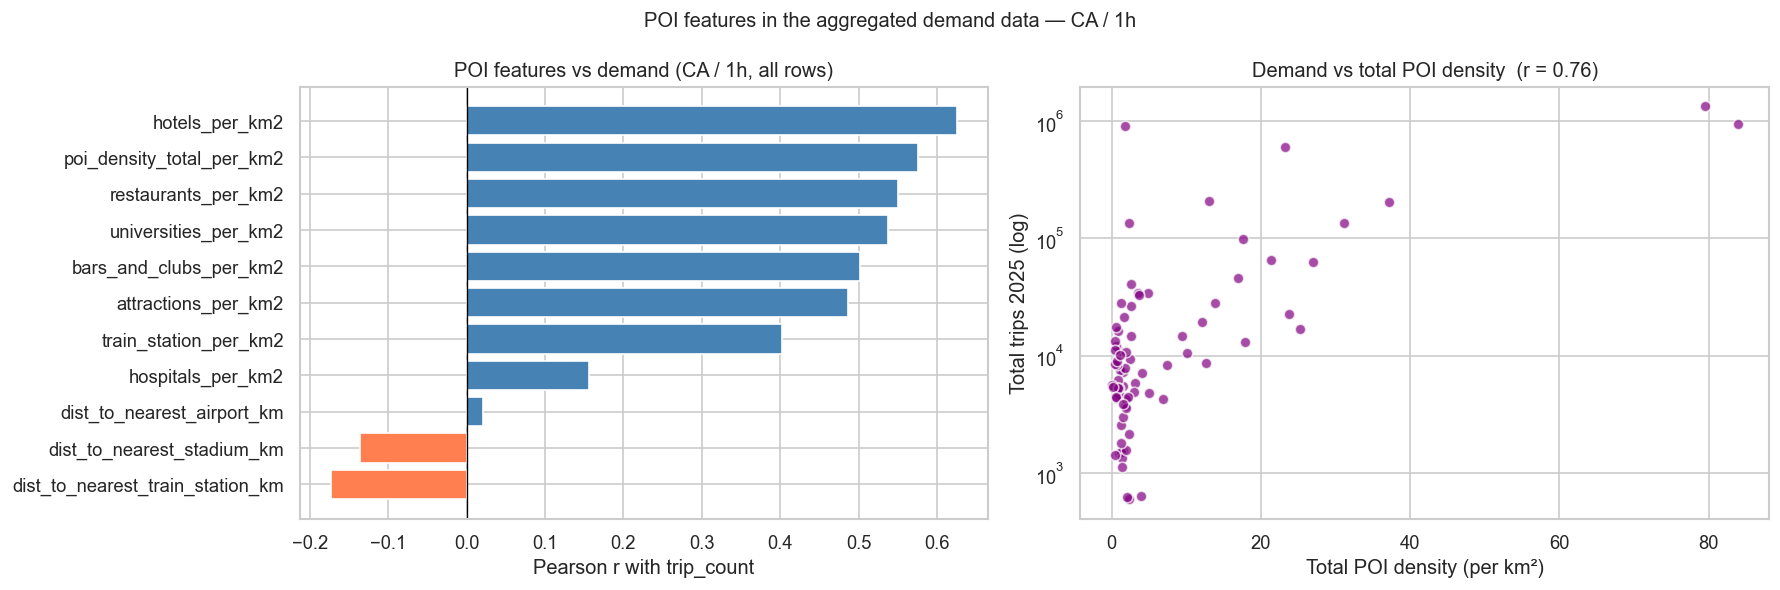

In [24]:
# POI features live in the aggregated datasets (added per cell by 01_07_Data_Aggregation).
POI_COLS = [
    "dist_to_nearest_airport_km", "dist_to_nearest_train_station_km", "dist_to_nearest_stadium_km",
    "train_station_per_km2", "restaurants_per_km2", "bars_and_clubs_per_km2", "hotels_per_km2",
    "hospitals_per_km2", "universities_per_km2", "attractions_per_km2", "poi_density_total_per_km2",
]
present = [c for c in POI_COLS if c in df1h_ca.columns]

if not present:
    print("No POI columns in the aggregated data yet \u2014 re-run 01_07_Data_Aggregation to add them.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # (a) how each POI feature correlates with demand
    corr = df1h_ca[present + ["trip_count"]].corr()["trip_count"].drop("trip_count").sort_values()
    axes[0].barh(corr.index, corr.values,
                 color=["coral" if v < 0 else "steelblue" for v in corr.values])
    axes[0].axvline(0, color="black", lw=0.8)
    axes[0].set_xlabel("Pearson r with trip_count")
    axes[0].set_title("POI features vs demand (CA / 1h, all rows)")

    # (b) total demand vs overall POI density, per community area
    per_ca = (df1h_ca.groupby("pickup_community_area")
              .agg(total_trips=("trip_count", "sum"),
                   poi_density=("poi_density_total_per_km2", "first"))
              .reset_index())
    axes[1].scatter(per_ca["poi_density"], per_ca["total_trips"],
                    s=40, alpha=0.7, color="purple", edgecolor="white")
    axes[1].set_yscale("log")
    axes[1].set_xlabel("Total POI density (per km\u00b2)")
    axes[1].set_ylabel("Total trips 2025 (log)")
    r = per_ca["poi_density"].corr(per_ca["total_trips"])
    axes[1].set_title(f"Demand vs total POI density  (r = {r:.2f})")

    plt.suptitle("POI features in the aggregated demand data \u2014 CA / 1h", fontsize=12)
    plt.tight_layout(); plt.show()